# Epileptic Seizure Detection and Classification

## 1.  Problem Definition & Dataset Selection
- **Domain**: Healthcare / Neurology
- **Problem**: Automated detection of epileptic seizures from EEG signals.
- **Dataset**: Bonn EEG Dataset (`BEED_Data.csv`)

In [63]:
import pandas as pd

In [64]:
import numpy as np

In [65]:
import matplotlib.pyplot as plt

In [66]:
import seaborn as sns

In [67]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

In [68]:
from sklearn.preprocessing import StandardScaler

In [69]:
from sklearn.linear_model import LogisticRegression

In [70]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [71]:
from sklearn.svm import SVC

In [72]:
from sklearn.neighbors import KNeighborsClassifier

In [73]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [74]:
from sklearn.decomposition import PCA

In [75]:
from sklearn.cluster import KMeans

In [76]:
import joblib

In [77]:
import warnings

In [78]:
warnings.filterwarnings('ignore')

## 2.  Data Preprocessing

In [79]:
# Load Dataset
df = pd.read_csv('BEED_Data.csv')

In [80]:
print("Dataset Shape:", df.shape)

Dataset Shape: (8000, 17)


In [81]:
print(df.head())

    X1   X2   X3   X4   X5   X6  X7  X8  X9  X10  X11  X12  X13  X14  X15  \
0    4    7   18   25   28   27  20  10 -10  -18  -20  -16   13   32   12   
1   87  114  120  106   76   54  28   5 -19  -49  -85 -102 -100  -89  -61   
2 -131 -133 -140 -131 -123 -108 -58 -51 -70  -77  -76  -76  -73  -57  -40   
3   68  104   73   34  -12  -26 -38 -36 -67  -88  -25   31   18   -4    6   
4  -67  -90  -97  -94  -86  -71 -43 -11  23   46   58   50   39   19   -9   

   X16  y  
0   10  0  
1  -21  0  
2  -14  0  
3  -29  0  
4  -41  0  


In [82]:
# Handle missing values
print("Missing Values:", df.isnull().sum().sum())

Missing Values: 0


In [83]:
# Target Transformation: 1=Seizure, 0=Non-Seizure
df['y'] = df['y'].apply(lambda x: 1 if x == 1 else 0)

In [84]:
feature_cols = [col for col in df.columns if col != 'y']

### 2.1 Outlier Analysis (Before Handling)

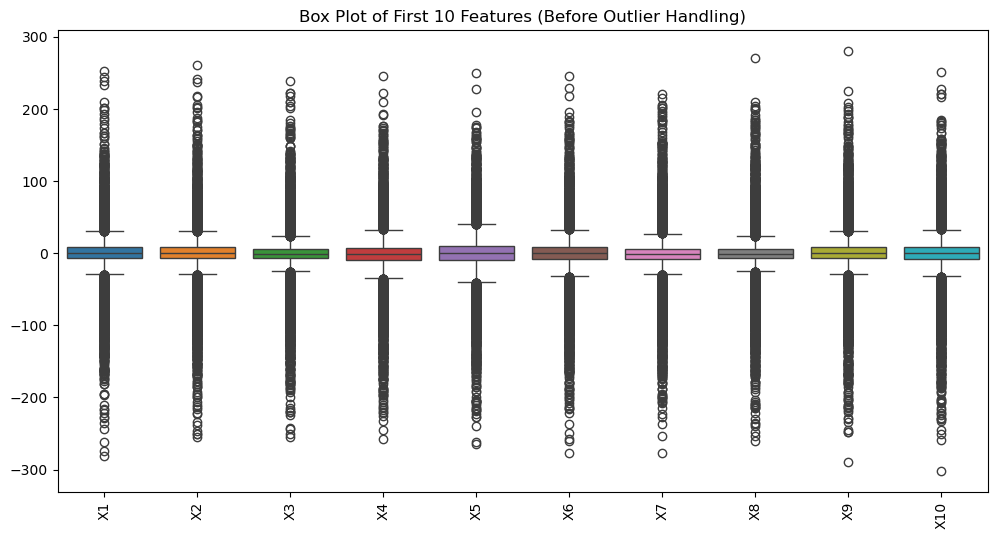

In [85]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[feature_cols[:10]])
plt.title('Box Plot of First 10 Features (Before Outlier Handling)')
plt.xticks(rotation=90)
plt.show()

In [86]:
# Identify and handle outliers using IQR
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Cap outliers instead of removing to preserve data continuity in EEG
        df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
        df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    return df

In [87]:
df = remove_outliers(df, feature_cols)
print("Outliers handled (capped).")

Outliers handled (capped).


### 2.2 Outlier Analysis (After Handling)

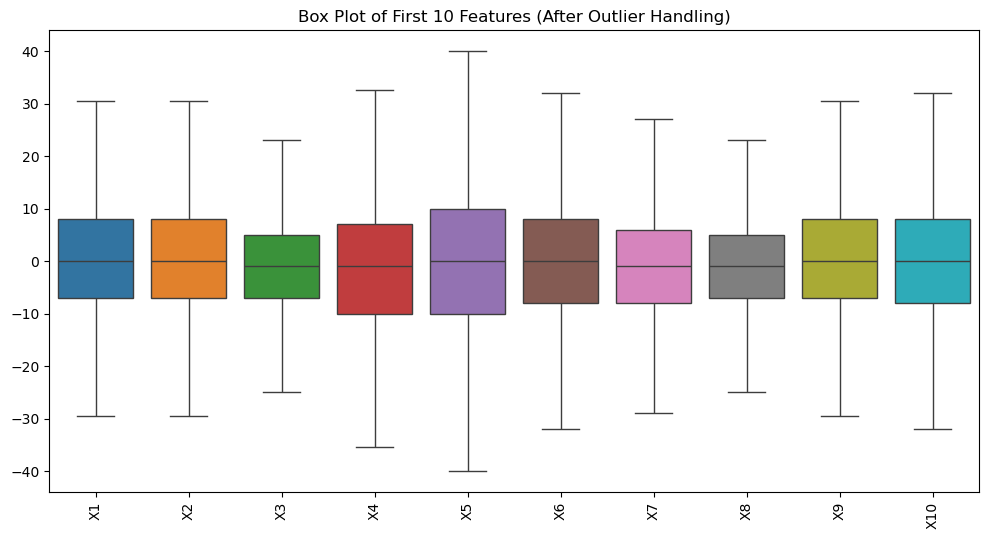

In [88]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[feature_cols[:10]])
plt.title('Box Plot of First 10 Features (After Outlier Handling)')
plt.xticks(rotation=90)
plt.show()

In [89]:
X = df.drop('y', axis=1)

In [90]:
y = df['y']

In [91]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [92]:
scaler = StandardScaler()

In [93]:
X_train_scaled = scaler.fit_transform(X_train)

In [94]:
X_test_scaled = scaler.transform(X_test)

## 3. Exploratory Data Analysis (EDA)

In [95]:
# 3.1 Descriptive Statistics
print("Descriptive Statistics:")
print(df.describe())

Descriptive Statistics:
                X1           X2           X3           X4           X5  \
count  8000.000000  8000.000000  8000.000000  8000.000000  8000.000000   
mean      0.391750    -0.060437    -1.206875    -2.297063    -0.227750   
std      16.071431    15.409254    12.815922    17.492219    20.697456   
min     -29.500000   -29.500000   -25.000000   -35.500000   -40.000000   
25%      -7.000000    -7.000000    -7.000000   -10.000000   -10.000000   
50%       0.000000     0.000000    -1.000000    -1.000000     0.000000   
75%       8.000000     8.000000     5.000000     7.000000    10.000000   
max      30.500000    30.500000    23.000000    32.500000    40.000000   

                X6           X7           X8           X9          X10  \
count  8000.000000  8000.000000  8000.000000  8000.000000  8000.000000   
mean     -0.345875    -1.515000    -1.392875     0.214562    -0.427625   
std      16.183641    14.622209    12.894875    16.382206    16.639670   
min     -32.0

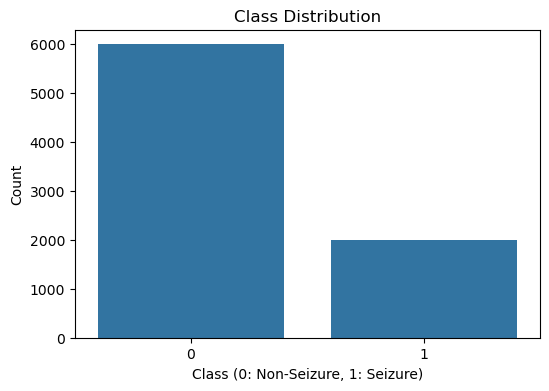

In [96]:
# 3.2 Class Distribution (Count Plot)
plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df)
plt.title('Class Distribution')
plt.xlabel('Class (0: Non-Seizure, 1: Seizure)')
plt.ylabel('Count')
plt.show()

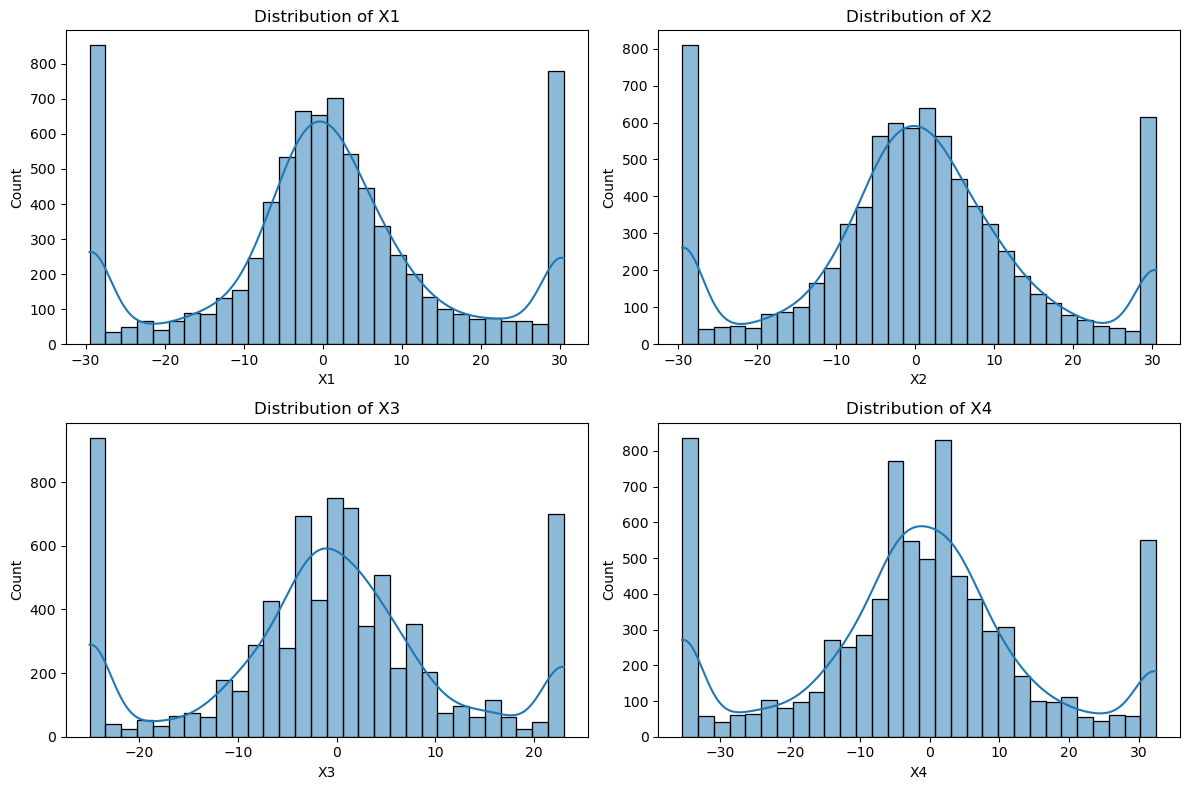

In [97]:
# 3.3 Histograms (Distribution of first 4 features)
plt.figure(figsize=(12, 8))
for i, col in enumerate(feature_cols[:4]):
    plt.subplot(2, 2, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

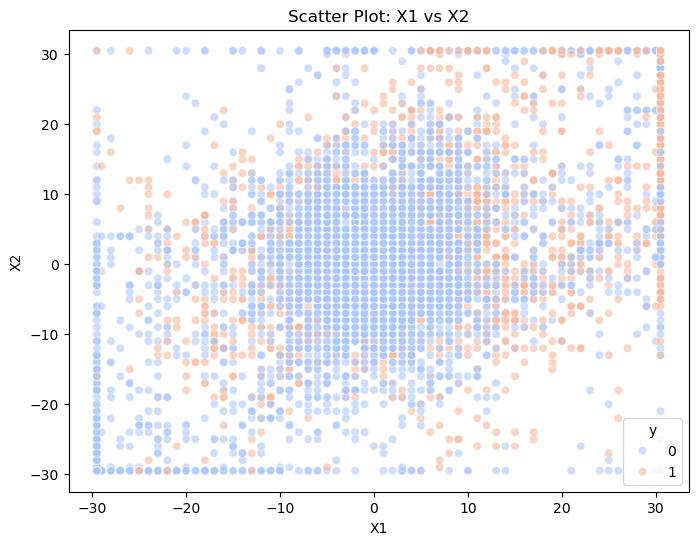

In [98]:
# 3.4 Scatter Plot (Relationship between first 2 features)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=feature_cols[0], y=feature_cols[1], hue='y', data=df, palette='coolwarm', alpha=0.6)
plt.title(f'Scatter Plot: {feature_cols[0]} vs {feature_cols[1]}')
plt.show()

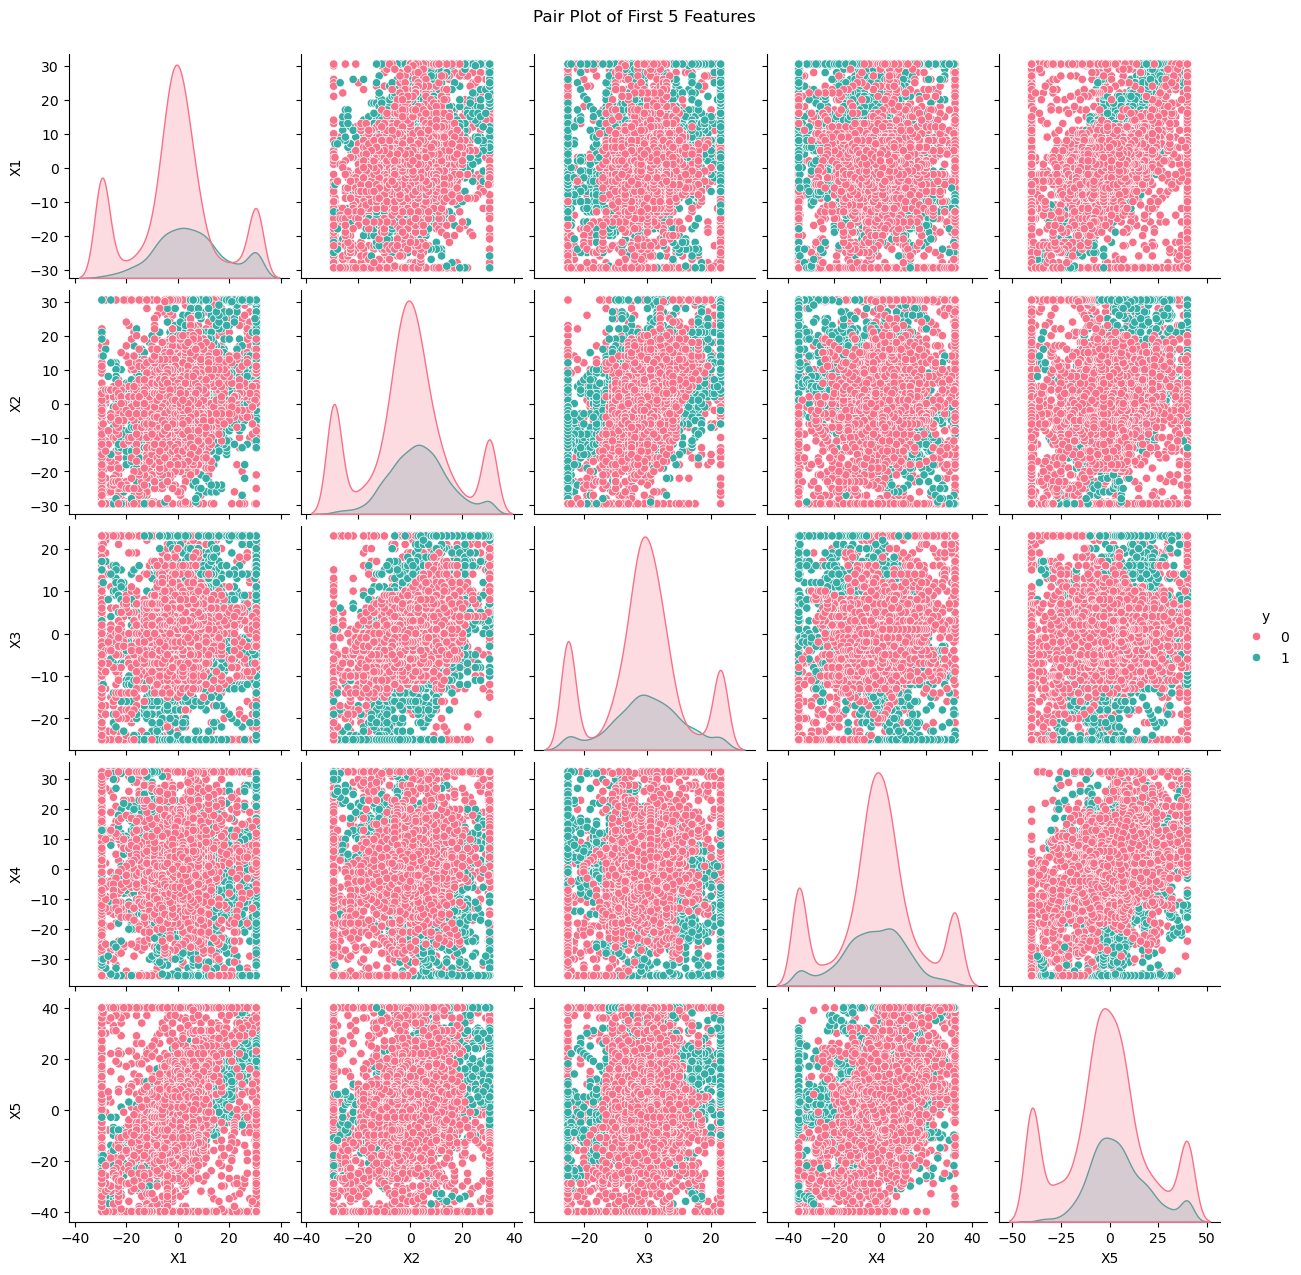

In [99]:
# 3.5 Pair Plot (Subset of features to avoid overcrowding)
# Using first 5 features + target
subset_cols = feature_cols[:5] + ['y']
sns.pairplot(df[subset_cols], hue='y', palette='husl')
plt.suptitle('Pair Plot of First 5 Features', y=1.02)
plt.show()

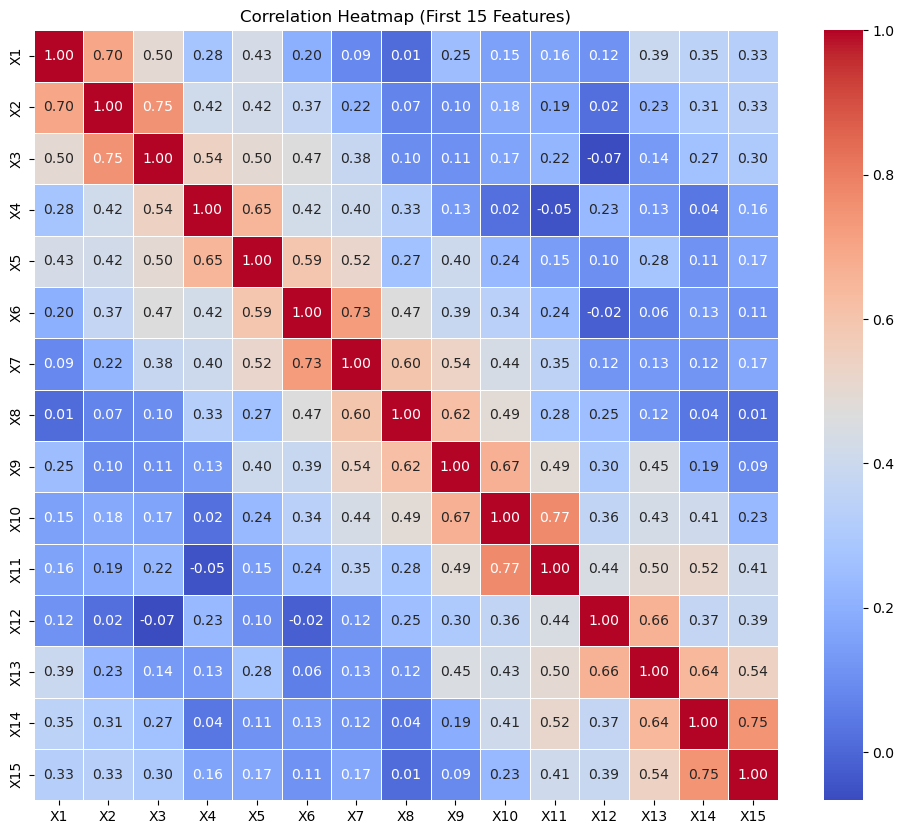

In [100]:
# 3.6 Correlation Heatmap
plt.figure(figsize=(12, 10))
corr_matrix = df[feature_cols[:15]].corr() # Correlation of first 15 features
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap (First 15 Features)')
plt.show()

## 4.  Model Development

In [101]:
results = [] # To store metrics for comparison

### 4.1 Logistic Regression

In [102]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

In [103]:
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

In [104]:
print("Logistic Regression Metrics:")
print(f"Accuracy: {acc_lr:.4f}")
print(f"Precision: {prec_lr:.4f}")
print(f"Recall: {rec_lr:.4f}")
print(f"F1-Score: {f1_lr:.4f}")

Logistic Regression Metrics:
Accuracy: 0.7794
Precision: 0.6691
Recall: 0.2325
F1-Score: 0.3451


In [105]:
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))


Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.96      0.87      1200
           1       0.67      0.23      0.35       400

    accuracy                           0.78      1600
   macro avg       0.73      0.60      0.61      1600
weighted avg       0.76      0.78      0.74      1600



In [106]:
results.append({"Model": "Logistic Regression", "Accuracy": acc_lr, "Precision": prec_lr, "Recall": rec_lr, "F1-Score": f1_lr})

### 4.2 Random Forest Classifier

In [107]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

In [108]:
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

In [109]:
print("Random Forest Metrics:")
print(f"Accuracy: {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall: {rec_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")

Random Forest Metrics:
Accuracy: 0.9825
Precision: 0.9921
Recall: 0.9375
F1-Score: 0.9640


In [110]:
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      1200
           1       0.99      0.94      0.96       400

    accuracy                           0.98      1600
   macro avg       0.99      0.97      0.98      1600
weighted avg       0.98      0.98      0.98      1600



In [111]:
results.append({"Model": "Random Forest", "Accuracy": acc_rf, "Precision": prec_rf, "Recall": rec_rf, "F1-Score": f1_rf})

### 4.3 Support Vector Machine (SVM)

In [112]:
svm = SVC(probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

In [113]:
acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

In [114]:
print("SVM Metrics:")
print(f"Accuracy: {acc_svm:.4f}")
print(f"Precision: {prec_svm:.4f}")
print(f"Recall: {rec_svm:.4f}")
print(f"F1-Score: {f1_svm:.4f}")

SVM Metrics:
Accuracy: 0.9450
Precision: 0.9588
Recall: 0.8150
F1-Score: 0.8811


In [115]:
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))


Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.99      0.96      1200
           1       0.96      0.81      0.88       400

    accuracy                           0.94      1600
   macro avg       0.95      0.90      0.92      1600
weighted avg       0.95      0.94      0.94      1600



In [116]:
results.append({"Model": "SVM", "Accuracy": acc_svm, "Precision": prec_svm, "Recall": rec_svm, "F1-Score": f1_svm})

### 4.4 K-Nearest Neighbors (KNN)

In [117]:
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

In [118]:
acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn)
rec_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

In [119]:
print("KNN Metrics:")
print(f"Accuracy: {acc_knn:.4f}")
print(f"Precision: {prec_knn:.4f}")
print(f"Recall: {rec_knn:.4f}")
print(f"F1-Score: {f1_knn:.4f}")

KNN Metrics:
Accuracy: 0.9706
Precision: 0.9862
Recall: 0.8950
F1-Score: 0.9384


In [120]:
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))


Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98      1200
           1       0.99      0.90      0.94       400

    accuracy                           0.97      1600
   macro avg       0.98      0.95      0.96      1600
weighted avg       0.97      0.97      0.97      1600



In [121]:
results.append({"Model": "KNN", "Accuracy": acc_knn, "Precision": prec_knn, "Recall": rec_knn, "F1-Score": f1_knn})

### 4.5 Gradient Boosting Classifier

In [122]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_scaled, y_train)
y_pred_gb = gb.predict(X_test_scaled)

In [123]:
acc_gb = accuracy_score(y_test, y_pred_gb)
prec_gb = precision_score(y_test, y_pred_gb)
rec_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)

In [124]:
print("Gradient Boosting Metrics:")
print(f"Accuracy: {acc_gb:.4f}")
print(f"Precision: {prec_gb:.4f}")
print(f"Recall: {rec_gb:.4f}")
print(f"F1-Score: {f1_gb:.4f}")

Gradient Boosting Metrics:
Accuracy: 0.9294
Precision: 0.9159
Recall: 0.7900
F1-Score: 0.8483


In [125]:
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))


Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.98      0.95      1200
           1       0.92      0.79      0.85       400

    accuracy                           0.93      1600
   macro avg       0.92      0.88      0.90      1600
weighted avg       0.93      0.93      0.93      1600



In [126]:
results.append({"Model": "Gradient Boosting", "Accuracy": acc_gb, "Precision": prec_gb, "Recall": rec_gb, "F1-Score": f1_gb})

### 4.6 Model Comparison

In [127]:
results_df = pd.DataFrame(results)
print("Model Comparison Table:")
print(results_df)

Model Comparison Table:
                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression  0.779375   0.669065  0.2325  0.345083
1        Random Forest  0.982500   0.992063  0.9375  0.964010
2                  SVM  0.945000   0.958824  0.8150  0.881081
3                  KNN  0.970625   0.986226  0.8950  0.938401
4    Gradient Boosting  0.929375   0.915942  0.7900  0.848322


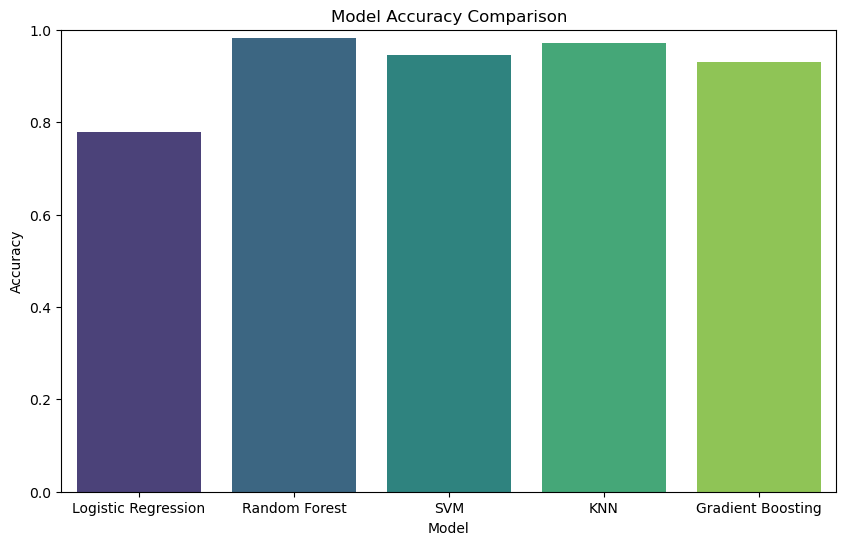

In [128]:
# Visualize Comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)
plt.show()

## 5.  Model Evaluation & Tuning

In [129]:
rf = RandomForestClassifier(random_state=42)

In [130]:
cv_scores = cross_val_score(rf, X_train_scaled, y_train, cv=5, scoring='accuracy')

In [131]:
print(f"Random Forest CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Random Forest CV Accuracy: 0.9752 (+/- 0.0077)


In [132]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

In [133]:
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='accuracy', n_jobs=-1)

In [134]:
grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [135]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}


In [136]:
best_rf = grid_search.best_estimator_

In [137]:
importances = best_rf.feature_importances_

In [138]:
indices = np.argsort(importances)[::-1][:10]

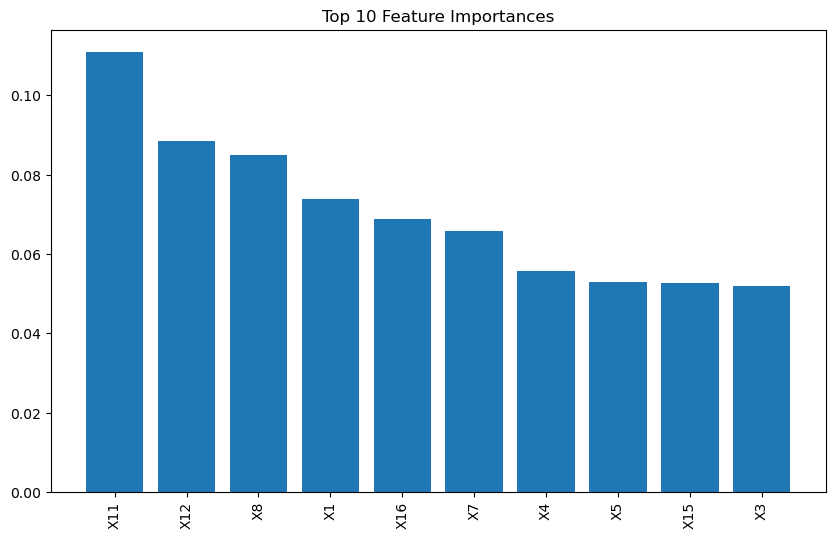

In [139]:
# Plotting Feature Importance
plt.figure(figsize=(10, 6))
plt.title("Top 10 Feature Importances")
plt.bar(range(10), importances[indices], align="center")
plt.xticks(range(10), [feature_cols[i] for i in indices], rotation=90)
plt.show()

## 6.  Unsupervised Learning Component

In [140]:
pca = PCA(n_components=2)

In [141]:
X_pca = pca.fit_transform(X_train_scaled)

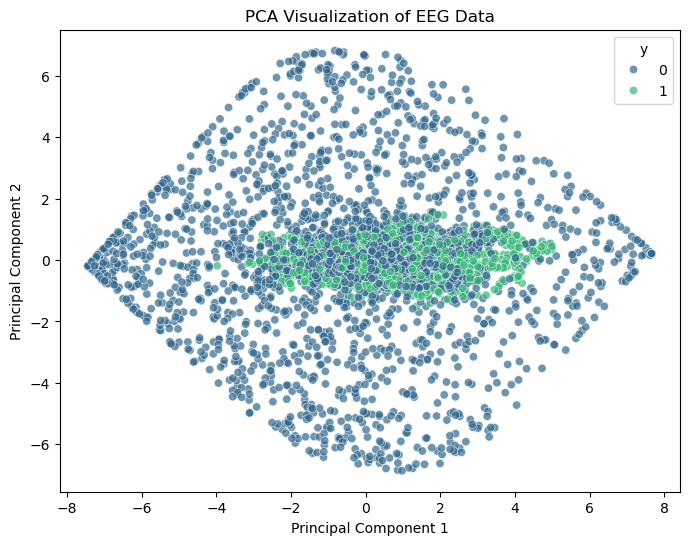

In [142]:
# Plotting PCA
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_train, palette='viridis', alpha=0.7)
plt.title('PCA Visualization of EEG Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [143]:
kmeans = KMeans(n_clusters=2, random_state=42)

In [144]:
clusters = kmeans.fit_predict(X_train_scaled)

In [145]:
conf_matrix_cluster = confusion_matrix(y_train, clusters)

In [146]:
print("Confusion Matrix (Clusters vs Actual):\n", conf_matrix_cluster)

Confusion Matrix (Clusters vs Actual):
 [[3932  868]
 [1450  150]]


## 7.  Model Deployment

In [147]:
joblib.dump(best_rf, 'epilepsy_model.pkl')

['epilepsy_model.pkl']

In [148]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [149]:
print("Model and Scaler saved successfully.")

Model and Scaler saved successfully.
